## CH331217 - NGÔ PHƯƠNG THẢO - MIDTERM KHOA HỌC DỮ LIỆU

### Đề bài: Phân tích doanh thu thị trường Denmark (Đan Mạch)

**Sinh viên thực hiện:**
* **Họ tên:** Ngô Phương Thảo
* **Mã sinh viên:** CH331217
* **Email:** CH331217@st.neu.edu.vn
* **Thị trường mục tiêu:** Denmark

---
### Giới thiệu dữ liệu
Tập dữ liệu giao dịch của một nhà bán lẻ trực tuyến tại Vương quốc Anh từ **01/12/2010** đến **09/12/2011**. Bài làm này sẽ tập trung khai thác "câu chuyện" doanh thu từ khách hàng và sản phẩm tại thị trường **Denmark**.


#### Bước 1: Khai báo và Làm sạch dữ liệu

In [81]:
import pandas as pd            
import matplotlib.pyplot as plt 
import seaborn as sns          

# Đọc file dữ liệu từ thư mục
df = pd.read_csv('OnlineRetail_DataModel.csv')

# Chuyển đổi định dạng: Thay ',' bằng '.' và ép kiểu về số thực (Float)
df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace(',', '.').astype(float)
df['TotalPrice'] = df['TotalPrice'].astype(str).str.replace(',', '.').astype(float)

#### Bước 2: Xác định thị trường phân tích

In [82]:
TARGET_ID = 18
COUNTRY_NAME = "Denmark"

# Lọc dữ liệu: Chỉ giữ lại các dòng thuộc về Denmark (ID 18)
df_denmark = df[df['CountryID'] == TARGET_ID].copy()

category_map = {
    1: "Giftware", 2: "Home Decor", 3: "Kitchenware", 4: "Stationery",
    5: "Accessories", 6: "Jewelry", 7: "Clothing", 8: "Household Items",
    9: "Toys & Games", 10: "Beauty & Health", 11: "Electronics", 
    12: "Garden & Outdoor", 13: "Others"
}

# Gán tên Category vào bảng dữ liệu chính
df['CategoryName'] = df['CategoryID'].map(category_map)

#### Bước 3: Tính toán các chỉ số kinh doanh chính (KPIs)

In [83]:
# 1. Tổng doanh thu (Revenue)
total_revenue = df_denmark['TotalPrice'].sum()

# 2. Tổng sản lượng hàng bán ra (Quantity)
total_quantity = df_denmark['Quantity'].sum()

# 3. Top 5 sản phẩm bán chạy nhất (Dựa trên số lượng)
top_products = df_denmark.groupby('ProductID')['Quantity'].sum().sort_values(ascending=False).head(5)

# 4. Doanh thu theo từng Nhóm hàng (Category)
category_sales = df_denmark.groupby('CategoryID')['TotalPrice'].sum().sort_values(ascending=False)

# 5. Khách hàng "Vip" nhất tại Denmark (Câu chuyện về lòng trung thành)
top_customer = df_denmark.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(1)
    
# 6. Sản phẩm "Ngôi sao" (Câu chuyện về sở thích)
top_products = df_denmark.groupby('ProductID')['Quantity'].sum().sort_values(ascending=False).head(5)

# 7. Nhóm hàng chủ lực (Câu chuyện về thị hiếu)
category_perf = df_denmark.groupby('CategoryID')['TotalPrice'].sum().sort_values(ascending=False)

#### Bước 4: TRỰC QUAN HÓA CÂU CHUYỆN (VISUALS)

Text(0, 0.5, 'Số lượng đã tiêu thụ')

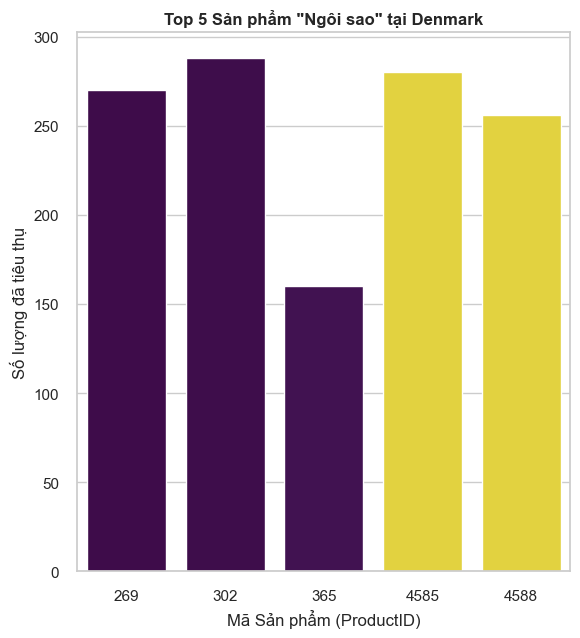

In [84]:
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid", palette="pastel")

# 4.1. Biểu đồ cột: Những sản phẩm "Ngôi sao" được săn đón nhất
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    x=top_products.index, 
    y=top_products.values, 
    hue=top_products.index, 
    palette='viridis'
)
if ax1.get_legend() is not None: ax1.get_legend().remove()
plt.title(f'Top 5 Sản phẩm "Ngôi sao" tại {COUNTRY_NAME}', fontsize=12, fontweight='bold')
plt.xlabel('Mã Sản phẩm (ProductID)')
plt.ylabel('Số lượng đã tiêu thụ')


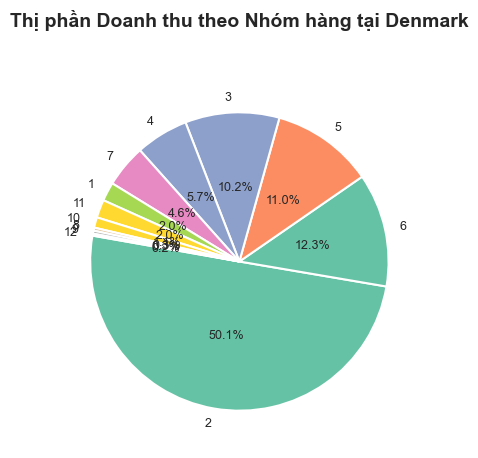

In [85]:
# 4.2. Biểu đồ tròn: Tỷ trọng doanh thu từ các "Nhóm hàng chủ lực"
plt.subplot(1, 2, 2)
category_perf.plot(
    kind='pie', 
    autopct='%0.1f%%', 
    startangle=170, 
    cmap='Set2', 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.5,    
    labeldistance=1.1, 
    textprops={'fontsize': 9}

)

plt.title(f'Thị phần Doanh thu theo Nhóm hàng tại {COUNTRY_NAME}', fontsize=14, fontweight='bold', pad=35)
plt.ylabel('') 

plt.tight_layout()
plt.show()

##### Danh mục sản phẩm (Category List)
1. Giftware
2. Home Decor
3. Kitchenware
4. Stationery
5. Accessories
6. Jewelry
7. Clothing
8. Household Items
9. Toys & Games
10. Beauty & Health
11. Electronics
12. Garden & Outdoor
13. Others

#### Bước 6: Trình bày kết quả và Ý nghĩa dữ liệu

In [86]:
# Sử dụng f-string và Dictionary-like access  in báo cáo
print(f"--- BÁO CÁO CHI TIẾT THỊ TRƯỜNG: {COUNTRY_NAME.upper()} ---")
print(f"Mã định danh hệ thống: {TARGET_ID}")
print("-" * 60)

# Kể chuyện
print(f"1. TỔNG QUAN: Thị trường đã đạt mức doanh thu ấn tượng {total_revenue:,.2f} USD ")
print(f"   với tổng cộng {total_quantity:,} sản phẩm được giao đến tay khách hàng.")

print(f"\n2. SẢN PHẨM NGÔI SAO: Mã hàng '{top_products.index[0]}' đang dẫn đầu thị hiếu ")
print(f"   với sản lượng bán ra đạt {top_products.values[0]} đơn vị.")

print(f"\n3. KHÁCH HÀNG VIP: Chân dung khách hàng mang mã số {int(top_customer.index[0])} ")
print(f"   đã đóng góp số tiền lớn nhất là {top_customer.values[0]:,.2f} USD vào doanh thu.")

print("-" * 60)
print("Dự báo: Cần tập trung ngân sách Marketing vào các nhóm hàng đang chiếm tỷ trọng cao.")

df_denmark.to_csv('denmark_final_report.csv', index=False)
print("=> Hệ thống: Đã lưu báo cáo sạch vào file 'denmark_final_report.csv'")

--- BÁO CÁO CHI TIẾT THỊ TRƯỜNG: DENMARK ---
Mã định danh hệ thống: 18
------------------------------------------------------------
1. TỔNG QUAN: Thị trường đã đạt mức doanh thu ấn tượng 18,768.14 USD 
   với tổng cộng 8,188 sản phẩm được giao đến tay khách hàng.

2. SẢN PHẨM NGÔI SAO: Mã hàng '302' đang dẫn đầu thị hiếu 
   với sản lượng bán ra đạt 288 đơn vị.

3. KHÁCH HÀNG VIP: Chân dung khách hàng mang mã số 12435 
   đã đóng góp số tiền lớn nhất là 7,829.89 USD vào doanh thu.
------------------------------------------------------------
Dự báo: Cần tập trung ngân sách Marketing vào các nhóm hàng đang chiếm tỷ trọng cao.
=> Hệ thống: Đã lưu báo cáo sạch vào file 'denmark_final_report.csv'
